In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [8]:
liver_df = pd.read_csv(r"C:\Users\abish\OneDrive\Desktop\Multiple Disease Prediction\data\indian_liver_patient - indian_liver_patient.csv")
kidney_df = pd.read_csv(r"C:\Users\abish\OneDrive\Desktop\Multiple Disease Prediction\data\kidney_disease - kidney_disease.csv")
parkinson_df = pd.read_csv(r"C:\Users\abish\OneDrive\Desktop\Multiple Disease Prediction\data\parkinsons - parkinsons.csv")

print(liver_df.shape, kidney_df.shape, parkinson_df.shape)


(583, 11) (400, 26) (195, 24)


In [9]:
# Check nulls and types
print(liver_df.isnull().sum())
print(kidney_df.isnull().sum())
print(parkinson_df.isnull().sum())


Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64
name                0
MDVP:Fo(Hz)         0
MDVP:F

----
### Preprocessing 

In [10]:
# ===== LIVER PREPROCESSING =====
liver_df['Gender'] = LabelEncoder().fit_transform(liver_df['Gender'])
liver_df.fillna(liver_df.median(), inplace=True)  # Only 4 nulls in 1 column

X_liver = liver_df.drop('Dataset', axis=1)
y_liver = liver_df['Dataset'].map({1: 1, 2: 0})

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_liver, y_liver, test_size=0.2, random_state=42)

print("Liver preprocessing done:", X_train_l.shape)


Liver preprocessing done: (466, 10)


In [11]:
# ===== KIDNEY PREPROCESSING =====
kidney_df.drop('id', axis=1, inplace=True)

# Strip spaces in target column
kidney_df['classification'] = kidney_df['classification'].str.strip()

# Separate numerical and categorical columns
num_cols = kidney_df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = kidney_df.select_dtypes(include='object').columns

# Fill numerical with median, categorical with mode
for col in num_cols:
    kidney_df[col].fillna(kidney_df[col].median(), inplace=True)

for col in cat_cols:
    kidney_df[col].fillna(kidney_df[col].mode()[0], inplace=True)

# Encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    kidney_df[col] = le.fit_transform(kidney_df[col])

X_kidney = kidney_df.drop('classification', axis=1)
y_kidney = kidney_df['classification']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kidney, y_kidney, test_size=0.2, random_state=42)

print("Kidney preprocessing done:", X_train_k.shape)


Kidney preprocessing done: (320, 24)


In [12]:
# ===== PARKINSON PREPROCESSING =====
parkinson_df.drop('name', axis=1, inplace=True)  # Drop name (not a feature)

X_park = parkinson_df.drop('status', axis=1)
y_park = parkinson_df['status']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_park, y_park, test_size=0.2, random_state=42)

print("Parkinson preprocessing done:", X_train_p.shape)


Parkinson preprocessing done: (156, 22)


---
## EDA

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Liver Disease — EDA Charts

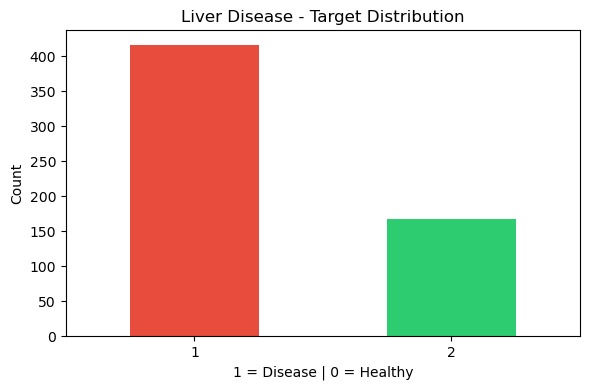

In [14]:
plt.figure(figsize=(6,4))
liver_df['Dataset'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Liver Disease - Target Distribution')
plt.xlabel('1 = Disease | 0 = Healthy')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

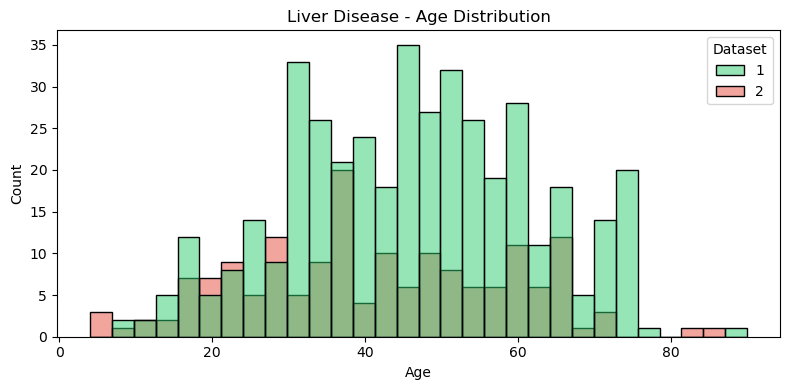

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(data=liver_df, x='Age', hue='Dataset', bins=30, palette=['#2ecc71','#e74c3c'])
plt.title('Liver Disease - Age Distribution')
plt.tight_layout()
plt.show()

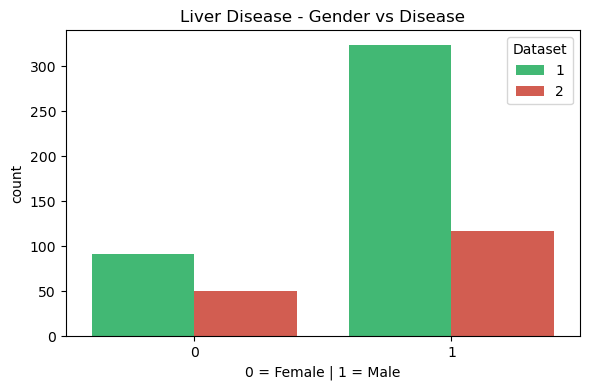

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=liver_df, x='Gender', hue='Dataset', palette=['#2ecc71','#e74c3c'])
plt.title('Liver Disease - Gender vs Disease')
plt.xlabel('0 = Female | 1 = Male')
plt.tight_layout()
plt.show()

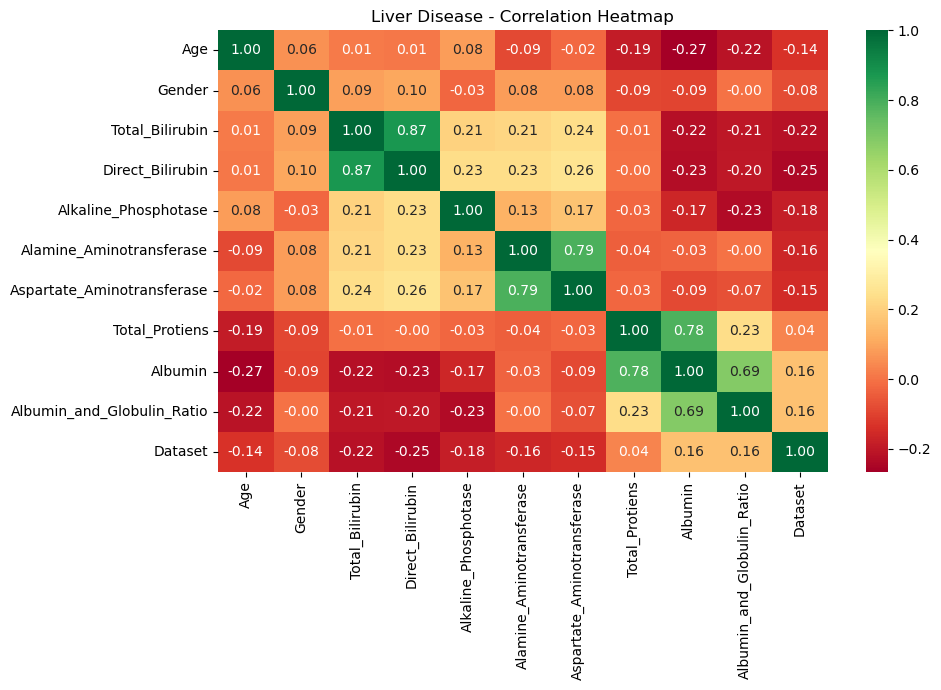

In [17]:
plt.figure(figsize=(10,7))
sns.heatmap(liver_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Liver Disease - Correlation Heatmap')
plt.tight_layout()
plt.show()

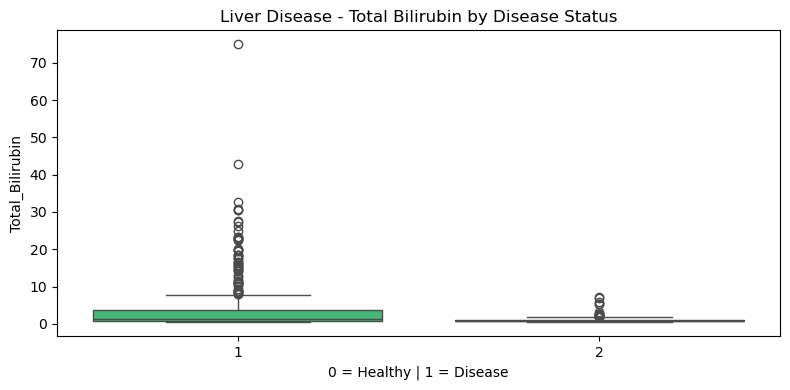

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(data=liver_df, x='Dataset', y='Total_Bilirubin', palette=['#2ecc71','#e74c3c'])
plt.title('Liver Disease - Total Bilirubin by Disease Status')
plt.xlabel('0 = Healthy | 1 = Disease')
plt.tight_layout()
plt.show()

##### Kidney Disease — EDA Charts

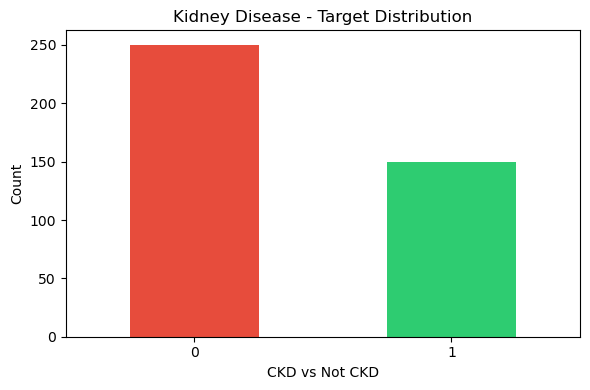

In [20]:
plt.figure(figsize=(6,4))
kidney_df['classification'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Kidney Disease - Target Distribution')
plt.xlabel('CKD vs Not CKD')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

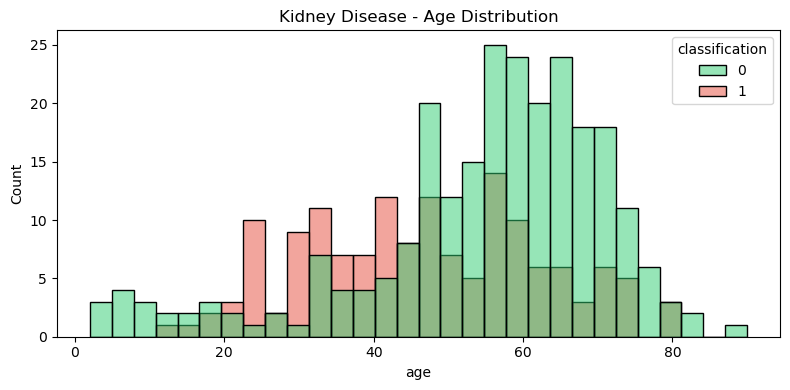

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(data=kidney_df, x='age', hue='classification', bins=30,
             palette=['#2ecc71','#e74c3c'])
plt.title('Kidney Disease - Age Distribution')
plt.tight_layout()
plt.show()

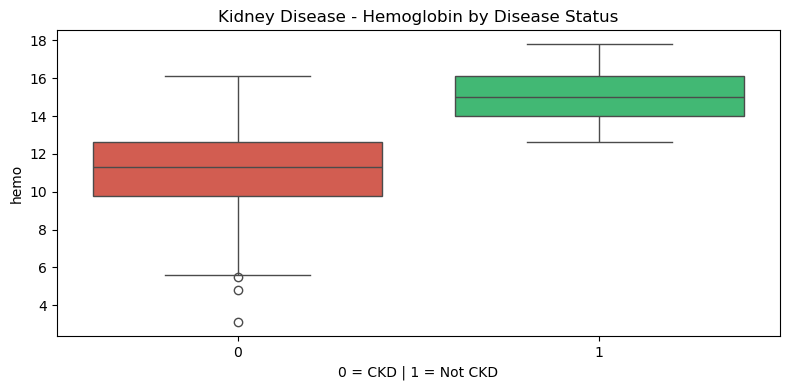

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(data=kidney_df, x='classification', y='hemo',
            palette=['#e74c3c','#2ecc71'])
plt.title('Kidney Disease - Hemoglobin by Disease Status')
plt.xlabel('0 = CKD | 1 = Not CKD')
plt.tight_layout()
plt.show()

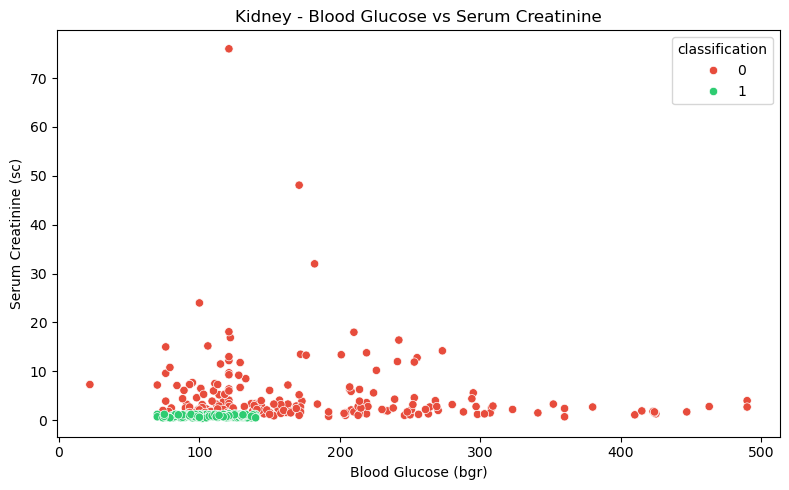

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=kidney_df, x='bgr', y='sc',
                hue='classification', palette=['#e74c3c','#2ecc71'])
plt.title('Kidney - Blood Glucose vs Serum Creatinine')
plt.xlabel('Blood Glucose (bgr)')
plt.ylabel('Serum Creatinine (sc)')
plt.tight_layout()
plt.show()

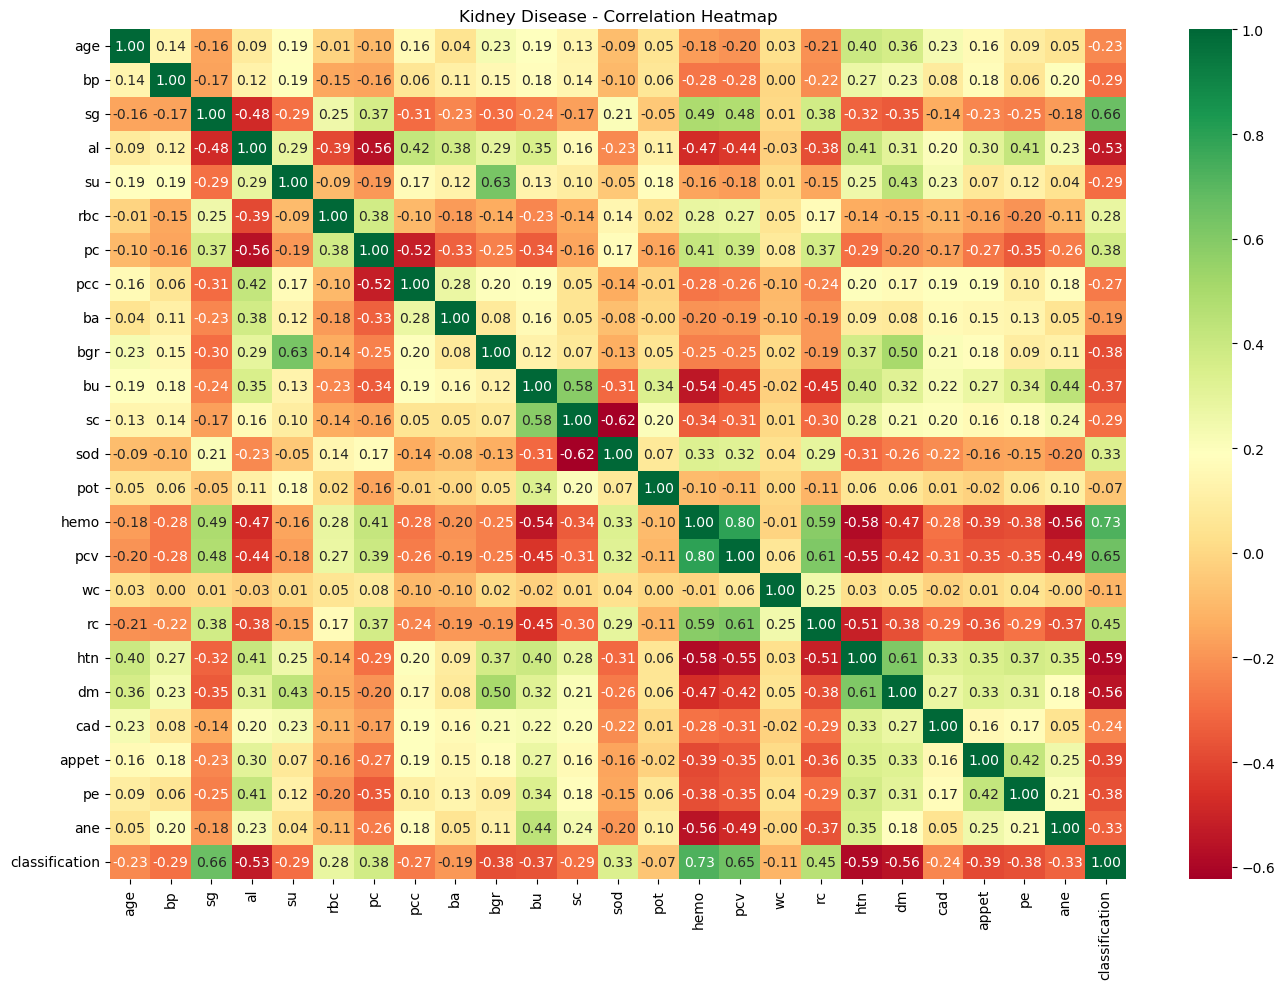

In [24]:
plt.figure(figsize=(14,10))
sns.heatmap(kidney_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Kidney Disease - Correlation Heatmap')
plt.tight_layout()
plt.show()

##### Parkinson's Disease — EDA Charts

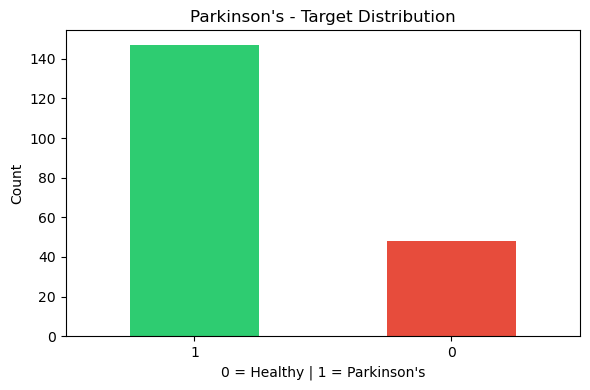

In [25]:
plt.figure(figsize=(6,4))
parkinson_df['status'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title("Parkinson's - Target Distribution")
plt.xlabel('0 = Healthy | 1 = Parkinson\'s')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

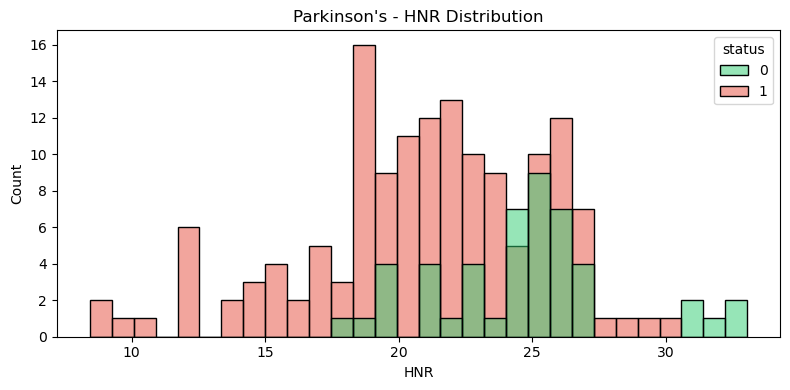

In [26]:
plt.figure(figsize=(8,4))
sns.histplot(data=parkinson_df, x='HNR', hue='status', bins=30,
             palette=['#2ecc71','#e74c3c'])
plt.title("Parkinson's - HNR Distribution")
plt.tight_layout()
plt.show()

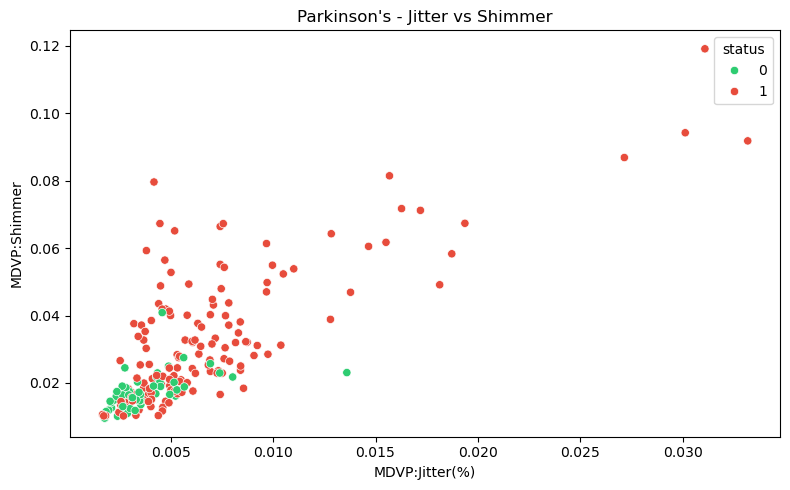

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=parkinson_df, x='MDVP:Jitter(%)', y='MDVP:Shimmer',
                hue='status', palette=['#2ecc71','#e74c3c'])
plt.title("Parkinson's - Jitter vs Shimmer")
plt.tight_layout()
plt.show()

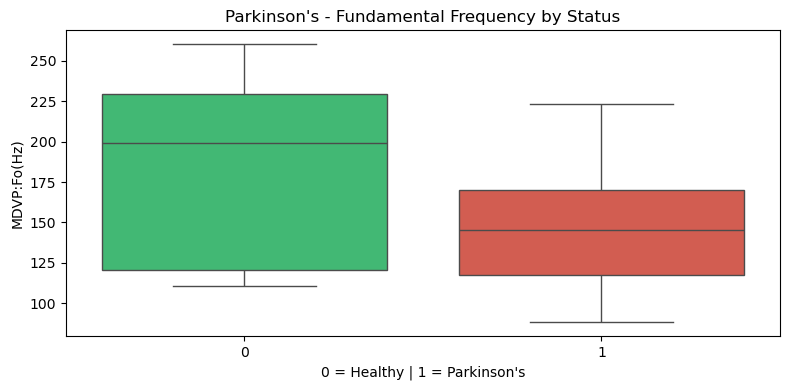

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(data=parkinson_df, x='status', y='MDVP:Fo(Hz)',
            palette=['#2ecc71','#e74c3c'])
plt.title("Parkinson's - Fundamental Frequency by Status")
plt.xlabel('0 = Healthy | 1 = Parkinson\'s')
plt.tight_layout()
plt.show()

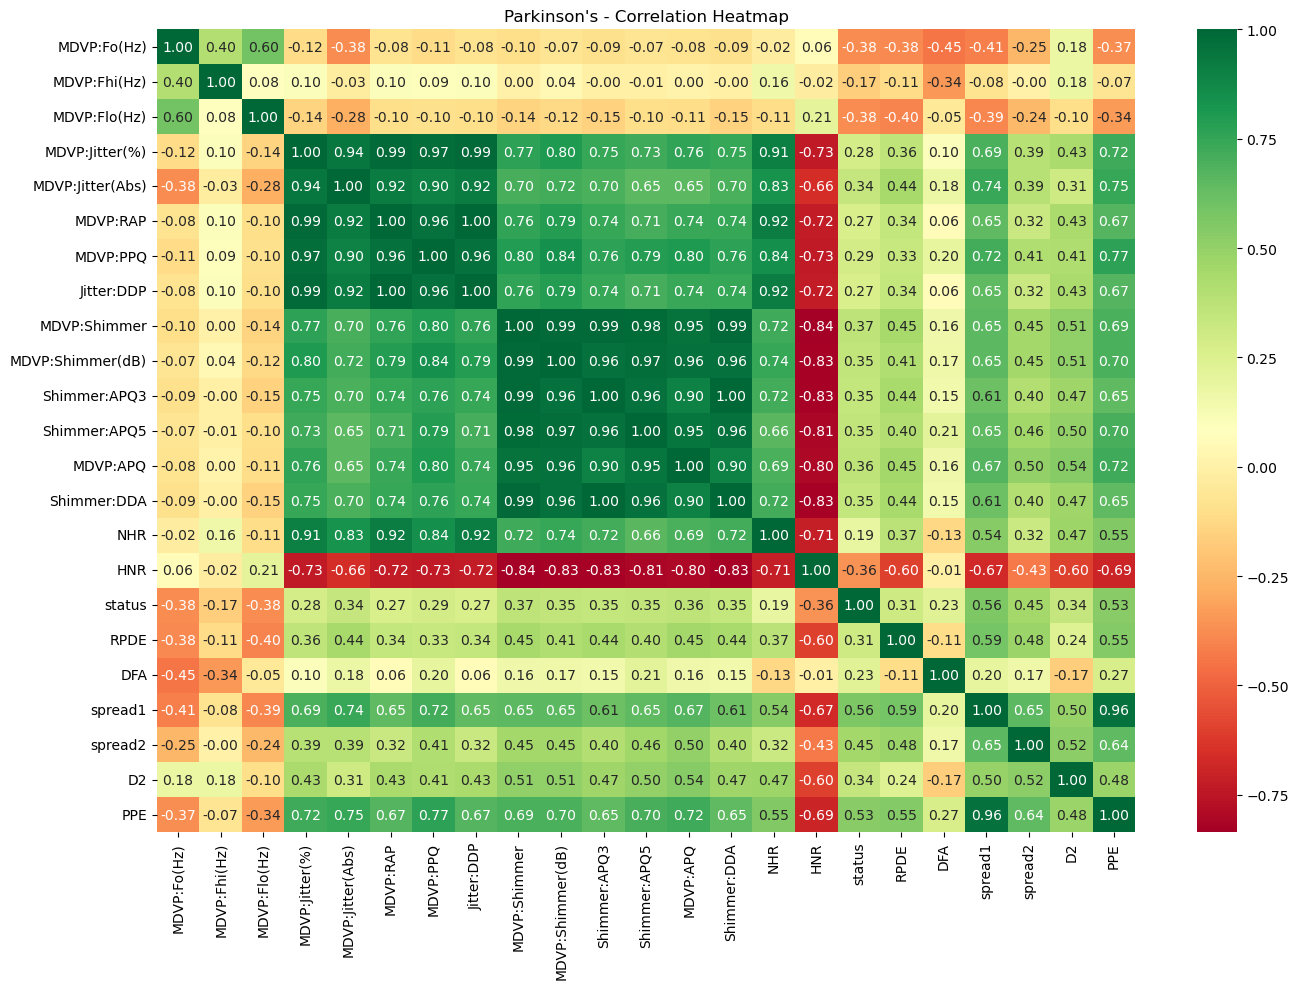

In [29]:
plt.figure(figsize=(14,10))
sns.heatmap(parkinson_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.title("Parkinson's - Correlation Heatmap")
plt.tight_layout()
plt.show()

---
## Train the Models

In [12]:
# Liver Model
liver_model = RandomForestClassifier(n_estimators=100, random_state=42)
liver_model.fit(X_train_l, y_train_l)
print("Liver Accuracy:", accuracy_score(y_test_l, liver_model.predict(X_test_l)))

# Kidney Model
kidney_model = RandomForestClassifier(n_estimators=100, random_state=42)
kidney_model.fit(X_train_k, y_train_k)
print("Kidney Accuracy:", accuracy_score(y_test_k, kidney_model.predict(X_test_k)))

# Parkinson Model
park_model = RandomForestClassifier(n_estimators=100, random_state=42)
park_model.fit(X_train_p, y_train_p)
print("Parkinson Accuracy:", accuracy_score(y_test_p, park_model.predict(X_test_p)))


Liver Accuracy: 0.7435897435897436
Kidney Accuracy: 1.0
Parkinson Accuracy: 0.9487179487179487


---
## Confusion Matrix


--- Liver ---
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        30
           1       0.81      0.86      0.83        87

    accuracy                           0.74       117
   macro avg       0.65      0.63      0.64       117
weighted avg       0.73      0.74      0.73       117



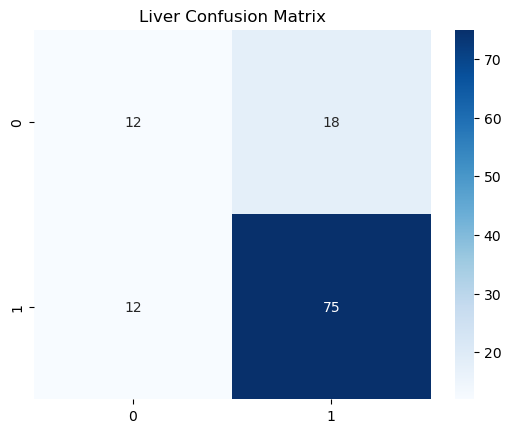


--- Kidney ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



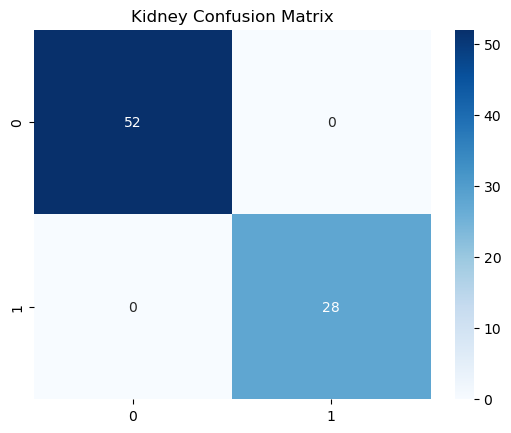


--- Parkinson ---
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



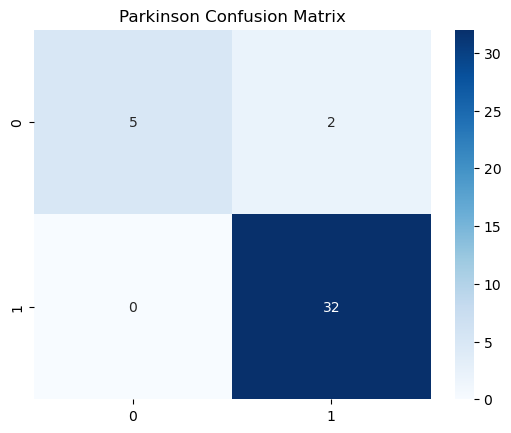

In [13]:
for name, model, X_test, y_test in [
    ("Liver", liver_model, X_test_l, y_test_l),
    ("Kidney", kidney_model, X_test_k, y_test_k),
    ("Parkinson", park_model, X_test_p, y_test_p)
]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, model.predict(X_test)))
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()


In [14]:
import pickle

with open('../models/liver_model.pkl', 'wb') as f:
    pickle.dump(liver_model, f)

with open('../models/kidney_model.pkl', 'wb') as f:
    pickle.dump(kidney_model, f)

with open('../models/parkinson_model.pkl', 'wb') as f:
    pickle.dump(park_model, f)

print("All models saved!")


All models saved!


----